<a href="https://colab.research.google.com/github/Ritesh-Gawande/Machine-Learning-Code/blob/main/Kmeans_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_iris

In [26]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [8]:
x = df.drop(['species'],axis=1)
y = df.species

In [10]:
x.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [11]:
from sklearn.cluster import KMeans

In [12]:
model = KMeans(n_clusters=3,random_state=42)

In [13]:
model.fit(x)

KMeans(n_clusters=3, random_state=42)

In [14]:
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [15]:
x1 = pd.DataFrame()
x1[0] = model.labels_
x1[1] = y.values
x1.rename(columns={0: "Kmeans"}, inplace=True)
x1.rename(columns={1: "Actual"}, inplace=True)
pd.set_option('display.max_row',None)
x1

,Kmeans,Actual
0,1,setosa
1,1,setosa
2,1,setosa
3,1,setosa
4,1,setosa
5,1,setosa
6,1,setosa
7,1,setosa
8,1,setosa
9,1,setosa


In [16]:
model.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [17]:
wcss = model.inertia_
wcss

78.85566582597727

In [18]:
wcss1 = []
x_list = []

for i in range(1,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit(x)
    wcss1.append(model.inertia_)
    x_list.append(i)

In [19]:
wcss1

[681.3705999999996,
 152.34795176035797,
 78.85566582597727,
 57.350880212954756,
 46.47223015873018,
 39.066035353535376,
 34.305815295815314,
 30.476222943722966,
 29.906246659137977,
 28.545297810033116]

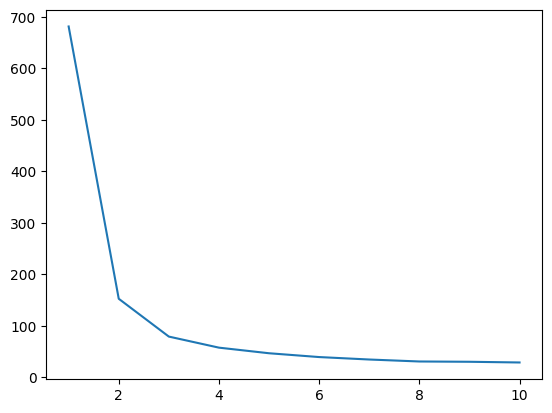

In [20]:
plt.plot(x_list,wcss1)
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
ss = silhouette_score(x,model.labels_)
ss

np.float64(0.3014143745325154)

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

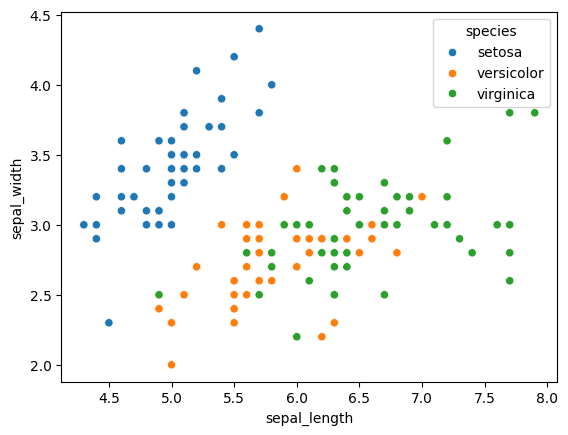

In [27]:
sns.scatterplot(x=df.sepal_length, y=df.sepal_width, data=df, hue=df.species)